## Exploratory Data Analysis

Workflow:
1. Load data and inspect structure
2. Check missing values
3. Check duplicate rows
4. Analyze target distribution (label, attack_cat)
5. Analyze nominal features (proto, service, state)
6. Analyze numerical features
7. Check correlation among numerical features

In [1]:
# 1. Load data and inspect structure

import pandas as pd

df_train = pd.read_parquet("../data/UNSW_NB15_training-set.parquet")
#df_test = pd.read_parquet("../data/UNSW_NB15_testing-set.parquet")

df_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [2]:
# 2. Check missing values

print(f"The dataframe has {df_train.shape[0]-df_train.dropna().shape[0]} invalid rows")

The dataframe has 0 invalid rows


In [3]:
# 3. Check duplicate rows

n_duplicates = df_train.duplicated().sum()
print(f"The dataframe has {n_duplicates} duplicate rows ({n_duplicates/len(df_train):.1%})")

The dataframe has 78519 duplicate rows (44.8%)


In [4]:
# 4. Analyze target distribution

print("Label distribution (0=normal, 1=attack)")
print(df_train['label'].value_counts(normalize=True).round(3)*100)

print("\nAttack category distribution:")
print(df_train['attack_cat'].value_counts())

Label distribution (0=normal, 1=attack)
label
1    68.1
0    31.9
Name: proportion, dtype: float64

Attack category distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [5]:
# 5. Analyze nominal features

for col in ['proto', 'service', 'state']:
    print(f"Column {col} --- {df_train[col].nunique()} unique values")
    print(f"{df_train[col].value_counts().head(10)}\n")

Column proto --- 133 unique values
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
swipe       201
mobile      201
Name: count, dtype: int64

Column service --- 13 unique values
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

Column state --- 9 unique values
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64



In [6]:
# 6. Analyze numerical features, including skewness

import numpy as np

numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('label')

skewness = df_train[numerical_cols].skew().sort_values(ascending=False)

print("Skewness per feature (top 10):")
print(skewness.head(10))

threshold = 1.0
n_above_threshold = (skewness > threshold).sum()
print(f"\n{n_above_threshold} features have skewness above {threshold}")

Skewness per feature (top 10):
trans_depth          167.335829
response_body_len     76.340075
sbytes                45.303443
sloss                 44.753662
dloss                 41.380270
spkts                 40.217703
dbytes                39.760864
dpkts                 36.764114
dinpkt                29.679512
djit                  29.543831
dtype: float64

29 features have skewness above 1.0


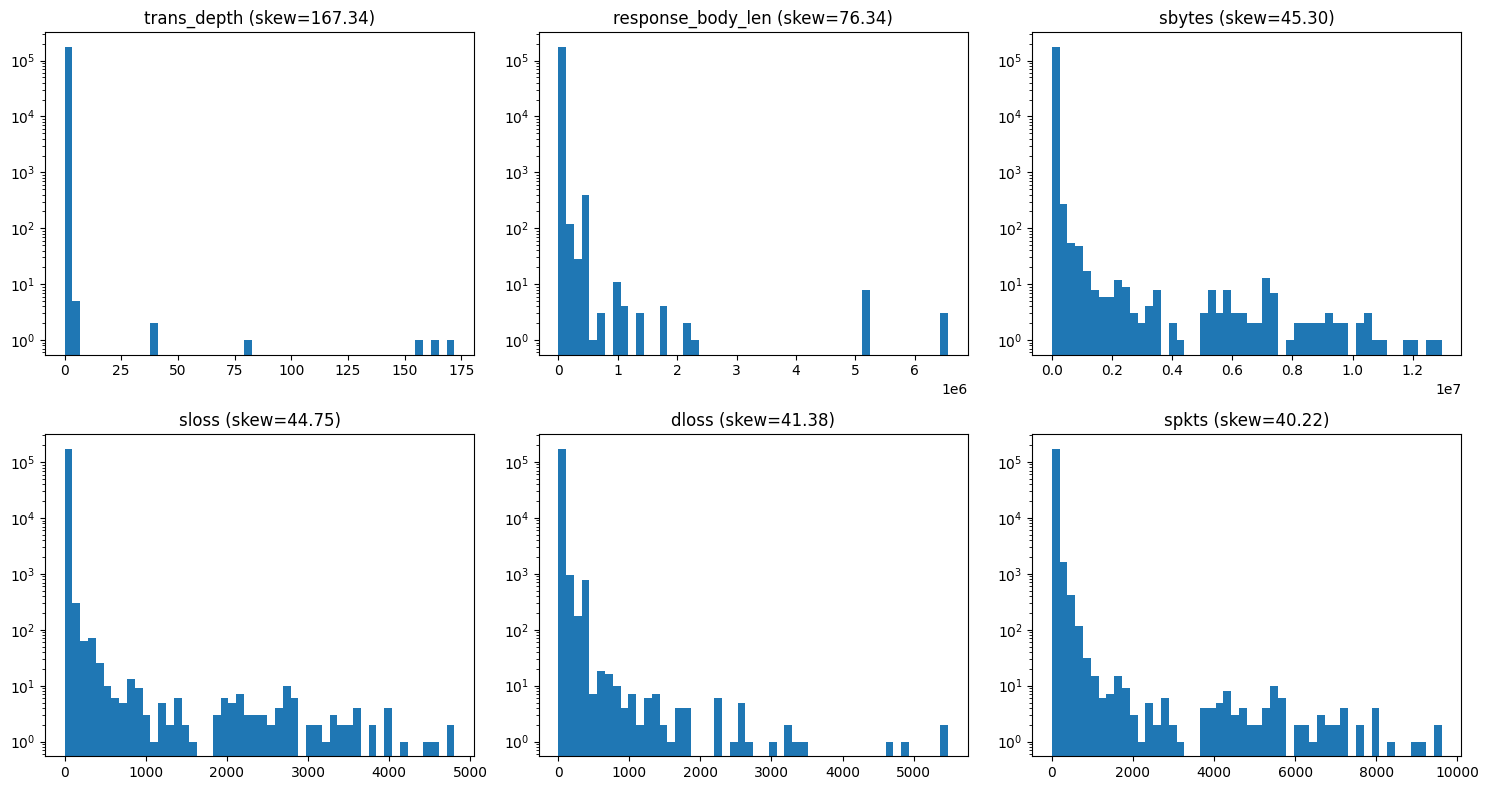

In [7]:
import matplotlib.pyplot as plt

top_skewed = skewness.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), top_skewed):
    ax.hist(df_train[col], bins=50)
    ax.set_yscale('log')  # log scale on y, to better show little bars
    ax.set_title(f"{col} (skew={skewness[col]:.2f})")

plt.tight_layout()
plt.show()

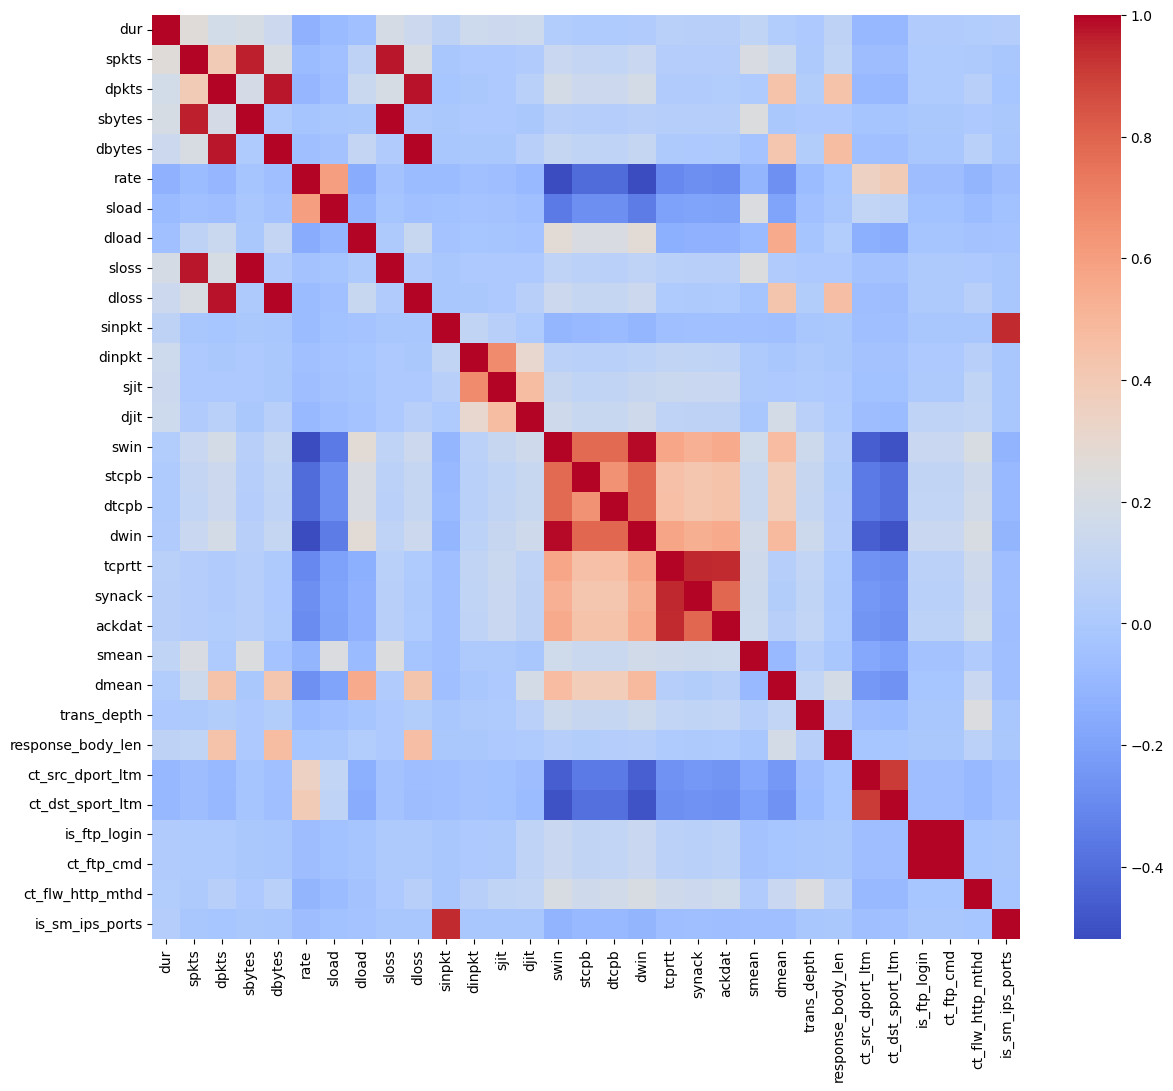

In [8]:
# 7. Check correlation among numerical features

import seaborn as sns

corr_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap = 'coolwarm')
plt.show()

In [9]:
corr_matrix_abs = df_train[numerical_cols].corr().abs()
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = upper.stack().sort_values(ascending=False)
print(high_corr[high_corr > 0.9])

is_ftp_login      ct_ftp_cmd          1.000000
dbytes            dloss               0.996504
sbytes            sloss               0.996109
swin              dwin                0.990140
dpkts             dloss               0.978636
                  dbytes              0.971907
spkts             sloss               0.971069
                  sbytes              0.963791
tcprtt            synack              0.949468
                  ackdat              0.941760
sinpkt            is_sm_ips_ports     0.941319
ct_src_dport_ltm  ct_dst_sport_ltm    0.906793
dtype: float64


## Note on feature correlation

Several pairs of numerical features show very high correlation (>= 0.9), in particular 'is_ftp_login' and 'ct_ftp_cmd' show perfect correlation (1.0), suggesting one is directly derived from the other. 

The redundancy was not addressed through manual feature removal, because tree-based models, such as Decision Tree and Random Forest, deal very well with multicollinearity. This was verified by retraining the best multiclass Random Forest model after dropping redundant features (keeping just one per highly correlated pair). The resulting Macro F1 in notebook 05 (0.553) was slightly lower than the original (0.566). This confirms that by removing these features there's no actual benefit and that the model already handles redundancy effectively on its own.